# Gemma-3-27B Natural Language Autoencoder Experiments

This notebook runs a focused set of experiments with a shared Gemma-3-27B target model and layer-41 Natural Language Autoencoder:

1. **Pooling Comparison** — compare AV explanations of mean-, last-, and max-pooled response activations.
2. **Round-trip Stability** — measure information drift through repeated verbalize→reconstruct cycles.
3. **Paraphrasing** — test reconstruction fidelity after controlled transformations of an AV explanation.
4. **Introspective Awareness** — inspect injected single- and multi-concept signals.
5. **Zero-vector Baseline** — inspect the AV prior when no activation direction is supplied.

Shared components:

- target model: `google/gemma-3-27b-it`
- activation verbalizer: `kitft/nla-gemma3-27b-L41-av`
- activation reconstructor: `kitft/nla-gemma3-27b-L41-ar`
- activation layer: 41
- introspection steering layer: 37

Edit the cluster configuration in the first code cell, restart the kernel, and run top-to-bottom.


## How To Run This Notebook

Use a fresh kernel and run cells from top to bottom. This version is meant for the same compute cluster, where each user has the same directory layout but a different `/home/<user>` name and possibly different assigned GPUs. Before running, edit the config block at the top of the first code cell. Daniel's defaults are: username `daniel`, visible GPUs `4,5`, SGLang GPU `5`, notebook device `cuda:0`. Other users should set their own username and allocated physical GPU IDs.

Prerequisites:

Cluster portability rule of thumb:

- In shell commands below, replace `<user>` with your Linux username.
- In the first code cell, set `USER_NAME` to the same username.
- For GPUs, enter the physical GPU IDs assigned by the scheduler/admin, for example `2,3`. After masking, the notebook sees the first listed GPU as `cuda:0`; the SGLang subprocess is separately pinned to the SGLang physical GPU you enter.

1. Clone or place the NLA repo at the path the setup cell will derive, by default:

   ```bash
   /home/<user>/natural_language_autoencoders
   ```

2. Install the NLA environment. This notebook expects the repo venv Python at:

   ```bash
   /home/<user>/natural_language_autoencoders/.venv/bin/python
   ```

3. Install SGLang the repo way, from a checkout rather than a wheel, then apply the NLA patches. The Gemma-3 `input_embeds` patch is included in this script.

   ```bash
   cd /home/<user>
   git clone https://github.com/sgl-project/sglang.git
   cd sglang
   git switch --detach v0.5.9  # known compatible with this notebook setup

   cd /home/<user>/natural_language_autoencoders
   bash patches/apply_sglang_patches.sh /home/<user>/sglang
   /home/<user>/.local/bin/uv pip install -e "/home/<user>/sglang/python[all]" \
       --python /home/<user>/natural_language_autoencoders/.venv/bin/python
   ```

   The patch script should verify these markers: HTTP transport, bf16-base64 transport, tokenizer numpy conversion, retract fix, chunked-prefill fix, and `gemma3_mm.py`.

4. Make sure Hugging Face access is ready. The base model `google/gemma-3-27b-it` may require accepting Google/Gemma terms and logging in:

   ```bash
   /home/kaylee/natural_language_autoencoders/.venv/bin/huggingface-cli login
   ```

5. Download the AV and AR checkpoints, or let the setup cell download them automatically with `huggingface_hub.snapshot_download()`. `nla_inference.py` needs a local checkpoint path because it reads `nla_meta.yaml` directly.

   Automatic mode uses these IDs directly:

   ```text
   kitft/nla-gemma3-27b-L41-av
   kitft/nla-gemma3-27b-L41-ar
   ```

   To pre-download them into the Hugging Face cache:

   ```bash
   /home/<user>/natural_language_autoencoders/.venv/bin/huggingface-cli download kitft/nla-gemma3-27b-L41-av
   /home/<user>/natural_language_autoencoders/.venv/bin/huggingface-cli download kitft/nla-gemma3-27b-L41-ar
   ```

   If your environment exposes the newer short command instead, `hf download ...` is equivalent. On this machine, the venv path above is the reliable one.

   To download them into explicit local folders instead:

   ```bash
   mkdir -p /home/kaylee/nla_checkpoints
   /home/kaylee/natural_language_autoencoders/.venv/bin/huggingface-cli download kitft/nla-gemma3-27b-L41-av \
       --local-dir /home/kaylee/nla_checkpoints/nla-gemma3-27b-L41-av
   /home/kaylee/natural_language_autoencoders/.venv/bin/huggingface-cli download kitft/nla-gemma3-27b-L41-ar \
       --local-dir /home/kaylee/nla_checkpoints/nla-gemma3-27b-L41-ar
   ```

   If you use explicit local folders, point the setup cell at those folders by setting environment variables before launching Jupyter:

   ```bash
   export NLA_ACTOR_DIR=/home/kaylee/nla_checkpoints/nla-gemma3-27b-L41-av
   export NLA_AR_DIR=/home/kaylee/nla_checkpoints/nla-gemma3-27b-L41-ar
   ```

   If you leave those unset, the notebook uses the Hugging Face repo IDs and resolves them to local cache snapshots automatically.

6. GPU layout for the defaults:

   ```text
   physical GPU 4 -> notebook local HF / AR work (cuda:0 after masking)
   physical GPU 5 -> SGLang AV server subprocess
   ```

Run order:

1. Restart the kernel so `CUDA_VISIBLE_DEVICES` is set before importing `torch`.
2. Run the setup cell and accept or edit the prompts.
3. Run the SGLang cell. It starts the AV server if `http://127.0.0.1:30000/health` is not already healthy.
4. Continue through the notebook.
5. Run the cleanup cell at the end to stop SGLang if this notebook launched it.

If your paths differ, set environment variables before launching Jupyter or edit them in the setup cell: `NLA_REPO`, `SGLANG_REPO`, `NLA_VENV_PYTHON`, `HF_HOME`, `NLA_EXPERIMENT_ROOT`, `NLA_ACTOR_DIR`, `NLA_AR_DIR`, and `SGLANG_URL`.


## Experiment Overview

All experiments share one AV server and use the same target tokenizer/model state where possible. The notebook deliberately unloads the 27B target before loading the AR, then reloads the target for introspection, so the full target and AR do not coexist on the notebook GPU.

Results are printed and displayed near the cells that produce them. Round-trip and paraphrasing summaries are also written beneath the configurable experiment output root; introspection and zero-vector results remain notebook-only.


In [1]:
from __future__ import annotations

# -----------------------------------------------------------------------------
# EDIT THESE VALUES FOR YOUR CLUSTER ALLOCATION
# -----------------------------------------------------------------------------
# USER_NAME is your Linux username / /home folder name.
# VISIBLE_GPUS are the physical GPU IDs assigned to you, comma-separated.
# After CUDA masking, the first listed physical GPU becomes cuda:0 in this notebook.
# SGLANG_PHYSICAL_GPU is the physical GPU reserved for the SGLang AV server.
USER_NAME = "kaylee"
VISIBLE_GPUS = "2,3"
SGLANG_PHYSICAL_GPU = "3"
LOCAL_DEVICE = "cuda:0"
# -----------------------------------------------------------------------------

# Run this notebook from a fresh kernel. CUDA_VISIBLE_DEVICES must be set before
# importing torch, so this setup cell intentionally defines paths/GPUs first.
import os
from pathlib import Path

HOME = Path("/home") / USER_NAME
NLA_REPO = Path(os.environ.get("NLA_REPO", HOME / "natural_language_autoencoders"))
SGLANG_REPO = Path(os.environ.get("SGLANG_REPO", HOME / "sglang"))
VENV_PYTHON = Path(os.environ.get("NLA_VENV_PYTHON", NLA_REPO / ".venv/bin/python"))
HF_CACHE = Path(os.environ.get("HF_HOME", HOME / ".cache/huggingface"))
ROOT = Path(os.environ.get("NLA_EXPERIMENT_ROOT", HOME / "experiments/nla_experiments"))
LIBNUMA_DIR = Path(
    os.environ.get(
        "NLA_LIBNUMA_DIR", NLA_REPO / "vendor/libnuma/usr/lib/x86_64-linux-gnu"
    )
)
PYTHON_INCLUDE_DIRS = [
    Path(
        os.environ.get(
            "NLA_PYTHON_INCLUDE",
            NLA_REPO / "vendor/python3.10-dev/usr/include/python3.10",
        )
    ),
    Path(
        os.environ.get(
            "NLA_PYTHON_MULTIARCH_INCLUDE",
            NLA_REPO / "vendor/python3.10-dev/usr/include",
        )
    ),
]
ROOT.mkdir(parents=True, exist_ok=True)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = VISIBLE_GPUS
os.environ["HF_HOME"] = str(HF_CACHE)
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
if LIBNUMA_DIR.exists():
    os.environ["LD_LIBRARY_PATH"] = (
        f"{LIBNUMA_DIR}:{os.environ.get('LD_LIBRARY_PATH', '')}"
    )
_existing_cpath = os.environ.get("CPATH", "")
_include_paths = [str(path) for path in PYTHON_INCLUDE_DIRS if path.exists()]
if _include_paths:
    os.environ["CPATH"] = ":".join([*_include_paths, _existing_cpath])

import gc
import math
import random
import re
import subprocess
import time
from contextlib import contextmanager
from typing import Any

import numpy as np
import torch
from huggingface_hub import snapshot_download
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

# Local NLA inference helpers from the released repo.
import sys

sys.path.insert(0, str(NLA_REPO))
from nla_inference import NLAClient, NLACritic

TARGET_MODEL = "google/gemma-3-27b-it"
ACTOR_REPO_ID = os.environ.get("NLA_ACTOR_DIR", "kitft/nla-gemma3-27b-L41-av")
AR_REPO_ID = os.environ.get("NLA_AR_DIR", "kitft/nla-gemma3-27b-L41-ar")
SGLANG_URL = os.environ.get("SGLANG_URL", "http://127.0.0.1:30000")
SGLANG_LOG = Path(os.environ.get("SGLANG_LOG", "/tmp/sglang_av_server.log"))
LAYER_INDEX = 41
DEVICE = LOCAL_DEVICE
SEED = 1234


def resolve_checkpoint(path_or_repo_id: str) -> str:
    """Return a local checkpoint path with nla_meta.yaml available."""
    candidate = Path(path_or_repo_id).expanduser()
    if candidate.exists():
        assert (
            candidate / "nla_meta.yaml"
        ).exists(), f"Missing nla_meta.yaml in {candidate}"
        return str(candidate)
    local_path = Path(snapshot_download(repo_id=path_or_repo_id))
    assert (
        local_path / "nla_meta.yaml"
    ).exists(), f"Missing nla_meta.yaml in downloaded snapshot {local_path}"
    return str(local_path)


ACTOR_DIR = resolve_checkpoint(ACTOR_REPO_ID)
AR_DIR = resolve_checkpoint(AR_REPO_ID)

assert NLA_REPO.exists(), f"Missing NLA repo: {NLA_REPO}"
assert SGLANG_REPO.exists(), f"Missing patched SGLang checkout: {SGLANG_REPO}"
assert VENV_PYTHON.exists(), f"Missing NLA venv Python: {VENV_PYTHON}"

print("home:", HOME)
print("NLA repo:", NLA_REPO)
print("SGLang checkout:", SGLANG_REPO)
print("HF cache:", HF_CACHE)
print("experiment output:", ROOT)
print("vendored libnuma:", LIBNUMA_DIR if LIBNUMA_DIR.exists() else "not found")
print("vendored Python includes:", [p for p in PYTHON_INCLUDE_DIRS if p.exists()])
print("visible physical GPUs:", VISIBLE_GPUS)
print("SGLang physical GPU:", SGLANG_PHYSICAL_GPU)
print("notebook device:", DEVICE)
print("actor checkpoint:", ACTOR_DIR)
print("AR checkpoint:", AR_DIR)
print(torch.__version__, torch.cuda.is_available())
if torch.cuda.is_available():
    print("visible cuda devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"cuda:{i}", torch.cuda.get_device_name(i))

/home/kaylee/natural_language_autoencoders/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 22 files: 100%|██████████| 22/22 [00:00<00:00, 38288.25it/s]


home: /home/kaylee
NLA repo: /home/kaylee/natural_language_autoencoders
SGLang checkout: /home/kaylee/sglang
HF cache: /home/kaylee/.cache/huggingface
experiment output: /home/kaylee/experiments/nla_experiments
vendored libnuma: not found
vendored Python includes: []
visible physical GPUs: 2,3
SGLang physical GPU: 3
notebook device: cuda:0
actor checkpoint: /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-av/snapshots/4e721238131ffb8348cff260fe81b8b34a270a0d
AR checkpoint: /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-ar/snapshots/aa2f29723c4807caf5f665dac004998df71b7cfb
2.9.1+cu128 True
visible cuda devices: 2
cuda:0 NVIDIA A100-SXM4-80GB
cuda:1 NVIDIA A100-SXM4-80GB


## Start The AV Server

The AV uses SGLang because the checkpoint expects `input_embeds` injection. This notebook launches the patched editable SGLang checkout through the NLA `.venv`, pinned to the physical GPU chosen in the setup cell.



In [2]:
def launch_sglang_actor() -> subprocess.Popen:
    env = os.environ.copy()
    env["HF_HOME"] = str(HF_CACHE)
    env["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    env["CUDA_VISIBLE_DEVICES"] = SGLANG_PHYSICAL_GPU
    env["SGLANG_MIN_NEW_TOKEN_RATIO_FACTOR"] = "1"
    env["PYTHONPATH"] = f"{NLA_REPO}:{env.get('PYTHONPATH', '')}"
    if LIBNUMA_DIR.exists():
        env["LD_LIBRARY_PATH"] = f"{LIBNUMA_DIR}:{env.get('LD_LIBRARY_PATH', '')}"
    include_paths = [str(path) for path in PYTHON_INCLUDE_DIRS if path.exists()]
    if include_paths:
        env["CPATH"] = ":".join([*include_paths, env.get("CPATH", "")])

    cmd = [
        str(VENV_PYTHON),
        "-m",
        "sglang.launch_server",
        "--model-path",
        ACTOR_DIR,
        "--port",
        "30000",
        "--host",
        "127.0.0.1",
        "--disable-radix-cache",
        "--mem-fraction-static",
        "0.80",
        "--context-length",
        "512",
        "--attention-backend",
        "triton",
        "--disable-cuda-graph",
        "--trust-remote-code",
        "--log-level",
        "warning",
    ]
    print("Launching SGLang on physical GPU", SGLANG_PHYSICAL_GPU)
    print(" ".join(cmd))
    print("SGLang server logs ->", SGLANG_LOG)
    log_f = open(SGLANG_LOG, "ab", buffering=0)
    return subprocess.Popen(
        cmd, env=env, cwd=str(NLA_REPO), stdout=log_f, stderr=subprocess.STDOUT
    )


def sglang_is_healthy() -> bool:
    import urllib.request

    try:
        urllib.request.urlopen(SGLANG_URL + "/health", timeout=2).read()
        return True
    except Exception:
        return False


def wait_for_sglang(timeout_s: int = 300) -> None:
    deadline = time.time() + timeout_s
    last_error = None
    while time.time() < deadline:
        if sglang_is_healthy():
            print("SGLang is healthy")
            return
        try:
            import urllib.request

            urllib.request.urlopen(SGLANG_URL + "/health", timeout=2).read()
        except Exception as exc:
            last_error = exc
        time.sleep(2)
    raise TimeoutError(f"SGLang did not become healthy: {last_error!r}")


sglang_proc = None
if sglang_is_healthy():
    print("SGLang is already healthy at", SGLANG_URL)
else:
    sglang_proc = launch_sglang_actor()
    wait_for_sglang()

SGLang is already healthy at http://127.0.0.1:30000


# Part I — Pooling Comparison

A response contains a sequence of layer-41 activation vectors, one per generated token. This experiment asks how three simple aggregation choices change what the AV reports:

- **mean:** average activation across the response;
- **last:** activation at the final response token;
- **max:** elementwise maximum across response positions.

For each of five prompts, Gemma generates one response, all response-token activations are captured at layer 41, each pooling method produces one vector, and the AV verbalizes all three. Pairwise word-set Jaccard scores quantify how different the explanations are.


In [3]:
import itertools

POOLING_PROMPTS = [
    "Explain why the sky sometimes looks red at sunset.",
    "Write a concise plan for organizing a small research sprint.",
    "Compare induction and deduction using a simple example.",
    "Describe how a compass works without using equations.",
    "Invent a short puzzle about a locked garden gate.",
]
POOLING_METHODS = ["mean", "last", "max"]
POOLING_GENERATION_MAX_NEW_TOKENS = 1000
POOLING_AV_MAX_NEW_TOKENS = 200
POOLING_TEMPERATURE = 1.0

print(f"Pooling run: {len(POOLING_PROMPTS)} prompts × {len(POOLING_METHODS)} methods")

Pooling run: 5 prompts × 3 methods


## Load The Target Model And AV Client

The target model supplies response activations. The AV client sends pooled layer-41 vectors to the SGLang server started above.


In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL,
    torch_dtype=torch.bfloat16,
    device_map={"": DEVICE},
    trust_remote_code=True,
    attn_implementation="eager",
).eval()
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

client = NLAClient(ACTOR_DIR, sglang_url=SGLANG_URL)
print("Target and AV client ready")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 12/12 [00:09<00:00,  1.31it/s]


[NLAClient] 4e721238131ffb8348cff260fe81b8b34a270a0d: d_model=5376 inj_scale=60000.0 embed_scale=73.32 inj_char='㈜'(id=246566)
Target and AV client ready


## Activation And Pooling Helpers

The helpers below format Gemma chat prompts, generate a response, capture block-output activations at selected token positions, pool the response sequence, and compare AV explanations.


In [5]:
def get_text_backbone(model: torch.nn.Module) -> torch.nn.Module:
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model
    if hasattr(model, "language_model"):
        language_model = model.language_model
        if hasattr(language_model, "model") and hasattr(language_model.model, "layers"):
            return language_model.model
        if hasattr(language_model, "layers"):
            return language_model
    raise TypeError(f"Could not find decoder layers on {type(model).__name__}")


@torch.inference_mode()
def capture_activation(
    model, input_ids, attention_mask, layer_index, token_pos
) -> np.ndarray:
    captured = {}

    def hook(_module, _inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        captured["activation"] = hidden[0, token_pos].detach().float().cpu()
        return output

    handle = get_text_backbone(model).layers[layer_index].register_forward_hook(hook)
    try:
        model(
            input_ids=input_ids.to(DEVICE),
            attention_mask=attention_mask.to(DEVICE),
            use_cache=False,
        )
    finally:
        handle.remove()
    return captured["activation"].numpy().astype(np.float32)


def format_user_prompt(user_prompt: str) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": user_prompt}],
        tokenize=False,
        add_generation_prompt=True,
    )


def token_count_for_pooling(text: str) -> int:
    return int(
        tokenizer(text, return_tensors="pt", add_special_tokens=False)[
            "input_ids"
        ].shape[1]
    )


@torch.inference_mode()
def generate_pooling_response(prompt: str, *, seed: int) -> str:
    set_seed(seed)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(DEVICE)
    input_length = inputs["input_ids"].shape[1]
    output_ids = model.generate(
        **inputs,
        do_sample=POOLING_TEMPERATURE > 0,
        temperature=POOLING_TEMPERATURE,
        max_new_tokens=POOLING_GENERATION_MAX_NEW_TOKENS,
        pad_token_id=tokenizer.pad_token_id,
    )
    response = tokenizer.decode(
        output_ids[0, input_length:], skip_special_tokens=True
    ).strip()
    if response.startswith("model\n"):
        response = response[len("model\n") :]
    return response.strip()


def pooling_response_positions(prompt: str, response: str) -> list[int]:
    return list(
        range(
            token_count_for_pooling(prompt), token_count_for_pooling(prompt + response)
        )
    )


@torch.inference_mode()
def extract_pooling_activations(text: str, positions: list[int], layer: int):
    inputs = tokenizer(text, return_tensors="pt", add_special_tokens=False).to(DEVICE)
    input_ids = inputs["input_ids"][0].detach().cpu()
    valid_positions = [
        position for position in positions if 0 <= position < len(input_ids)
    ]
    captured = {}

    def hook(_module, _inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        for position in valid_positions:
            captured[position] = hidden[0, position].detach().float().cpu()
        return output

    handle = get_text_backbone(model).layers[layer].register_forward_hook(hook)
    try:
        model(**inputs, use_cache=False)
    finally:
        handle.remove()

    return [
        {
            "token_position": position,
            "token_id": int(input_ids[position].item()),
            "token_text": tokenizer.decode([int(input_ids[position].item())]),
            "activation": captured[position],
        }
        for position in valid_positions
    ]


def pool_response_activations(rows, method: str) -> torch.Tensor:
    if not rows:
        raise ValueError("Cannot pool an empty response")
    activations = torch.stack([row["activation"] for row in rows], dim=0)
    if method == "mean":
        return activations.mean(dim=0)
    if method == "last":
        return activations[-1]
    if method == "max":
        return activations.max(dim=0).values
    raise ValueError(method)


def explanation_jaccard(a: str, b: str) -> float:
    words_a = set(re.findall(r"[a-zA-Z]{3,}", a.lower()))
    words_b = set(re.findall(r"[a-zA-Z]{3,}", b.lower()))
    if not words_a and not words_b:
        return 1.0
    if not words_a or not words_b:
        return 0.0
    return len(words_a & words_b) / len(words_a | words_b)

## Run The Pooling Comparison

Each response is generated once and reused for all three pooling methods. Explanations are printed as soon as the AV returns them, then collected in `pooling_rows` for direct notebook inspection.


In [6]:
pooling_rows = []

for prompt_index, user_prompt in enumerate(POOLING_PROMPTS):
    print("=" * 80)
    print(
        f"PROMPT [{prompt_index + 1}/{len(POOLING_PROMPTS)}] {user_prompt}", flush=True
    )
    formatted_prompt = format_user_prompt(user_prompt)
    response = generate_pooling_response(formatted_prompt, seed=SEED + prompt_index)
    print(f"\nMODEL RESPONSE:\n{response}\n", flush=True)

    positions = pooling_response_positions(formatted_prompt, response)
    activation_rows = extract_pooling_activations(
        formatted_prompt + response,
        positions,
        LAYER_INDEX,
    )
    print(f"Captured {len(activation_rows)} response-token activations", flush=True)

    explanations = {}
    pooled_vectors = {}
    for method in POOLING_METHODS:
        pooled_vector = pool_response_activations(activation_rows, method)
        pooled_vectors[method] = pooled_vector
        explanation = client.generate(
            pooled_vector,
            max_new_tokens=POOLING_AV_MAX_NEW_TOKENS,
            temperature=POOLING_TEMPERATURE,
        )
        explanations[method] = explanation
        print(f"\n--- {method.upper()} POOL ---\n{explanation}", flush=True)

    comparisons = {
        f"{left}_vs_{right}": explanation_jaccard(
            explanations[left], explanations[right]
        )
        for left, right in itertools.combinations(POOLING_METHODS, 2)
    }
    print("\nJaccard comparisons:", comparisons, flush=True)

    for method in POOLING_METHODS:
        pooling_rows.append(
            {
                "prompt_index": prompt_index,
                "prompt": user_prompt,
                "generated_text": response,
                "nla_layer": LAYER_INDEX,
                "pooling_method": method,
                "num_response_positions": len(activation_rows),
                "pooled_activation_norm": float(pooled_vectors[method].norm().item()),
                "nla_explanation": explanations[method],
                "pairwise_jaccard": comparisons,
            }
        )

assert len(pooling_rows) == len(POOLING_PROMPTS) * len(POOLING_METHODS)
display(pooling_rows)
print(f"Completed {len(pooling_rows)} pooling rows; results were not written to disk.")

PROMPT [1/5] Explain why the sky sometimes looks red at sunset.

MODEL RESPONSE:
The red skies we often see at sunset (and sunrise!) are a beautiful example of a phenomenon called **Rayleigh scattering**. Here's a breakdown of what's happening:

**1. Sunlight and Colors:**

* Sunlight is actually made up of *all* the colors of the rainbow. You can see this when light passes through a prism and separates into its component colors.
* Each color has a different wavelength.  Blue and violet have shorter wavelengths, while red and orange have longer wavelengths.

**2. The Atmosphere and Scattering:**

* As sunlight enters the Earth's atmosphere, it collides with tiny air molecules (mostly nitrogen and oxygen). 
* This collision causes the light to **scatter** - meaning it gets deflected in different directions.
* **Rayleigh scattering** specifically refers to the scattering of electromagnetic radiation (like sunlight) by particles of a much smaller wavelength.  This is *much* more effective

[{'prompt_index': 0,
  'prompt': 'Explain why the sky sometimes looks red at sunset.',
  'generated_text': "The red skies we often see at sunset (and sunrise!) are a beautiful example of a phenomenon called **Rayleigh scattering**. Here's a breakdown of what's happening:\n\n**1. Sunlight and Colors:**\n\n* Sunlight is actually made up of *all* the colors of the rainbow. You can see this when light passes through a prism and separates into its component colors.\n* Each color has a different wavelength.  Blue and violet have shorter wavelengths, while red and orange have longer wavelengths.\n\n**2. The Atmosphere and Scattering:**\n\n* As sunlight enters the Earth's atmosphere, it collides with tiny air molecules (mostly nitrogen and oxygen). \n* This collision causes the light to **scatter** - meaning it gets deflected in different directions.\n* **Rayleigh scattering** specifically refers to the scattering of electromagnetic radiation (like sunlight) by particles of a much smaller wave

Completed 15 pooling rows; results were not written to disk.


# Part II — Reconstruction Fidelity

The AV maps an activation to text and the AR maps that text back to activation space. The next two experiments measure how faithfully information survives this interface:

- **Round-trip Stability:** repeat AV→AR cycles and compare every hop with the original activation.
- **Paraphrasing:** transform one AV explanation in several ways and compare each reconstruction with the same original activation.

Before loading the AR, all required target activations and paraphrase variants are prepared while the target model is still resident. The target is then unloaded so the AR can use the notebook GPU.


In [8]:
import itertools
import json
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt

EXPERIMENT_OUTPUT_DIR = ROOT / "results"
EXPERIMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Gemma-3-27B / layer-41 predict-the-mean MSE from the training set.
VAR_NRM = 0.0579
ROUND_TRIP_N_VALUES = [1, 2, 5, 10, 20]
ROUND_TRIP_AV_TEMPERATURE = 1.0  # Set to 0.0 for deterministic AV decoding.
ROUND_TRIP_AV_MAX_NEW_TOKENS = 200
PARAPHRASE_AV_TEMPERATURE = 0.0


def fve(mse_nrm: float) -> float:
    """Fraction of training-set activation variance explained."""
    return 1.0 - float(mse_nrm) / VAR_NRM


def to_jsonable(value):
    if isinstance(value, torch.Tensor):
        return (
            value.detach().cpu().item()
            if value.ndim == 0
            else value.detach().cpu().tolist()
        )
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {key: to_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(item) for item in value]
    return value


def write_json(path: Path, value) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(to_jsonable(value), f, ensure_ascii=False, indent=2)


print("Experiment outputs:", EXPERIMENT_OUTPUT_DIR)
print("Gemma-27B/L41 VAR_NRM:", VAR_NRM)

Experiment outputs: /home/kaylee/experiments/nla_experiments/results
Gemma-27B/L41 VAR_NRM: 0.0579


## Prepare Activations And Paraphrase Variants

The target model is still resident after Pooling Comparison. Capture the five round-trip activations and the paraphrasing activation now, then build the text transformations before switching from the target model to the AR.


In [9]:
assert "model" in globals(), "Run the target-model loading cell before this section."
assert "client" in globals(), "Run the AV-client cell before this section."


@torch.inference_mode()
def extract_plain_text_activation(
    text: str, layer: int = LAYER_INDEX, position: int = -1
) -> np.ndarray:
    batch = tokenizer(text, return_tensors="pt", add_special_tokens=True)
    return capture_activation(
        model,
        batch["input_ids"],
        batch["attention_mask"],
        layer,
        position,
    )


def verbalize_vector(
    vector, *, temperature: float = 1.0, max_new_tokens: int = 200
) -> str:
    return client.generate(
        vector,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
    )


ROUND_TRIP_PROMPTS = [
    "The quick brown fox jumps over the lazy dog.",
    "In quantum mechanics, the wave function collapses upon measurement.",
    "She sold seashells by the seashore.",
]

PARAPHRASE_PHRASE = (
    "The cabinet meeting on the following day regarding Jo's fate is described "
    "in detail in the Annals of the Jos"
)

print("Capturing round-trip vectors...")
round_trip_vectors = [
    extract_plain_text_activation(prompt) for prompt in ROUND_TRIP_PROMPTS
]
paraphrase_activation = extract_plain_text_activation(PARAPHRASE_PHRASE)
paraphrase_explanation = verbalize_vector(
    paraphrase_activation,
    temperature=PARAPHRASE_AV_TEMPERATURE,
    max_new_tokens=260,
)

print(
    f"Captured {len(round_trip_vectors)} round-trip vectors: {round_trip_vectors[0].shape}"
)
print(
    "Paraphrase activation:",
    paraphrase_activation.shape,
    f"norm={np.linalg.norm(paraphrase_activation):.1f}",
)
print("\nCurrent NLA explanation:\n", paraphrase_explanation)

Capturing round-trip vectors...
Captured 3 round-trip vectors: (5376,)
Paraphrase activation: (5376,) norm=39595.9

Current NLA explanation:
 Encyclopedic/educational register: a formal wiki-style entry describing a fictional empire, likely a historical or political narrative about Joseon/Imperial Korea.

The phrase "The History of the Jos" signals a list or example of a fictional story about the imperial rebellion, likely a historical narrative or political intrigue involving the Emperor.

Final token "of the Jos" begins a noun phrase describing a named entity or object ("in the Jos"), strongly expecting a noun like "dynasty" or "Kingdom" or "Court" to complete a reference to the political romance or rebellion. or "ian Empire" or "s." or "Family, the..." or "War." or "the."


In [10]:
TRANSFORMATION_INSTRUCTIONS = {
    "Para light": "Paraphrase lightly. Preserve every claim, paragraph order, and level of detail, but change the wording.",
    "Para aggressive": "Paraphrase aggressively. Preserve meaning and uncertainty, but substantially change wording, syntax, and organization.",
    "French": "Translate faithfully into French. Preserve quoted fragments and uncertainty where appropriate.",
    "Coherence": "Rewrite as a coherent explanation. Resolve awkward phrasing without adding facts or removing substantive claims.",
    "Summary": "Summarize in one concise paragraph while retaining the central format, context, and final-token prediction.",
}


@torch.inference_mode()
def transform_explanation(instruction: str, explanation_text: str) -> str:
    messages = [
        {
            "role": "user",
            "content": (
                instruction
                + "\n\nReturn only the transformed explanation, with no preface or commentary."
                + "\n\nEXPLANATION:\n"
                + explanation_text
            ),
        }
    ]
    input_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(DEVICE)
    output_ids = model.generate(
        input_ids=input_ids,
        do_sample=False,
        max_new_tokens=320,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(
        output_ids[0, input_ids.shape[1] :], skip_special_tokens=True
    ).strip()


paragraphs = [
    part.strip() for part in paraphrase_explanation.split("\n\n") if part.strip()
]
paraphrase_variants = {"Shuffle": "\n\n".join(reversed(paragraphs))}
for variant_name, instruction in TRANSFORMATION_INSTRUCTIONS.items():
    print("Building", variant_name, flush=True)
    paraphrase_variants[variant_name] = transform_explanation(
        instruction, paraphrase_explanation
    )

PARAPHRASE_VARIANT_METHOD = "current-run transformations"
display([{"name": name, "text": text} for name, text in paraphrase_variants.items()])

Building Para light


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Building Para aggressive
Building French
Building Coherence
Building Summary


[{'name': 'Shuffle',
  'text': 'Final token "of the Jos" begins a noun phrase describing a named entity or object ("in the Jos"), strongly expecting a noun like "dynasty" or "Kingdom" or "Court" to complete a reference to the political romance or rebellion. or "ian Empire" or "s." or "Family, the..." or "War." or "the."\n\nThe phrase "The History of the Jos" signals a list or example of a fictional story about the imperial rebellion, likely a historical narrative or political intrigue involving the Emperor.\n\nEncyclopedic/educational register: a formal wiki-style entry describing a fictional empire, likely a historical or political narrative about Joseon/Imperial Korea.'},
 {'name': 'Para light',
  'text': 'This text adopts a scholarly, informative tone, resembling a formal entry from an online encyclopedia, and likely details a fabricated empire with roots in Korean history or political structures, potentially drawing from the Joseon dynasty or Imperial Korea.\n\nThe title “The Histo

## Switch From The Target Model To The AR

All required activations and transformation texts are now stored in CPU memory. Free the 27B target model and load the AR for reconstruction and scoring.


In [11]:
del model
gc.collect()
torch.cuda.empty_cache()

critic = NLACritic(AR_DIR, device=DEVICE, dtype=torch.bfloat16)


def score_reconstruction(reconstructed, original) -> tuple[float, float]:
    pred = torch.as_tensor(reconstructed, dtype=torch.float32)
    gold = torch.as_tensor(np.asarray(original, dtype=np.float32))
    pred_n = pred / pred.norm().clamp_min(1e-12) * critic.mse_scale
    gold_n = gold / gold.norm().clamp_min(1e-12) * critic.mse_scale
    mse_nrm = ((pred_n - gold_n) ** 2).mean().item()
    cosine = torch.nn.functional.cosine_similarity(pred_n, gold_n, dim=0).item()
    return mse_nrm, cosine


def reconstruct_and_score(
    explanation_text: str, original
) -> tuple[np.ndarray, float, float]:
    """Reconstruct once, then score against the original vector."""
    reconstructed = critic.reconstruct(explanation_text).numpy().astype(np.float32)
    mse_nrm, cosine = score_reconstruction(reconstructed, original)
    return reconstructed, mse_nrm, cosine


print("AR ready — mse_scale:", critic.mse_scale)

Loading checkpoint shards: 100%|██████████| 8/8 [00:00<00:00, 162.47it/s]
Some weights of Gemma3ForCausalLM were not initialized from the model checkpoint at /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-ar/snapshots/aa2f29723c4807caf5f665dac004998df71b7cfb and are newly initialized: ['model.norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[NLACritic] 42 layers  d_model=5376  mse_scale=73.32
AR ready — mse_scale: 73.32121111929344


## Round-trip Stability

Start from each real layer-41 activation and run sequential AV→AR cycles. Every reconstructed hop is scored against the **original** vector, revealing cumulative drift rather than only one-step consistency.

The reported hop set is `N ∈ {1, 2, 5, 10, 20}`. AV temperature is configurable above; use `0.0` for deterministic decoding.


In [12]:
def multi_trip_with_text(original_vector: np.ndarray, n: int):
    current = original_vector.copy()
    hops = []
    for hop_index in range(1, n + 1):
        explanation_text = verbalize_vector(
            current,
            temperature=ROUND_TRIP_AV_TEMPERATURE,
            max_new_tokens=ROUND_TRIP_AV_MAX_NEW_TOKENS,
        )
        print(f"\n--- AV HOP {hop_index}/{n} ---", flush=True)
        print(explanation_text, flush=True)
        reconstructed, mse_nrm, cosine = reconstruct_and_score(
            explanation_text,
            original_vector,
        )
        print(
            f"AR metrics: mse={mse_nrm:.4f}  cos={cosine:.4f}  fve={fve(mse_nrm):.3f}",
            flush=True,
        )
        hops.append(
            {
                "hop": hop_index,
                "text": explanation_text,
                "mse_nrm": mse_nrm,
                "cos": cosine,
                "fve_nrm": fve(mse_nrm),
            }
        )
        current = reconstructed
    return hops


round_trip_all_hops = []
for prompt_index, (vector, prompt) in enumerate(
    zip(round_trip_vectors, ROUND_TRIP_PROMPTS)
):
    print("=" * 80)
    print(f"PROMPT [{prompt_index}]: {prompt}")
    print("=" * 80)
    hops = multi_trip_with_text(vector, max(ROUND_TRIP_N_VALUES))
    round_trip_all_hops.append(hops)
    print(f"\nCompleted {len(hops)} hops for prompt {prompt_index}.", flush=True)

round_trip_summary = []
for n in ROUND_TRIP_N_VALUES:
    rows = [hops[n - 1] for hops in round_trip_all_hops]
    mses = [row["mse_nrm"] for row in rows]
    coss = [row["cos"] for row in rows]
    round_trip_summary.append(
        {
            "N": n,
            "mse_nrm_mean": float(np.mean(mses)),
            "mse_nrm_std": float(np.std(mses)),
            "cos_mean": float(np.mean(coss)),
            "fve_nrm": fve(float(np.mean(mses))),
        }
    )

display(round_trip_summary)
write_json(
    EXPERIMENT_OUTPUT_DIR / "01_round_trip_stability.json",
    {
        "model": TARGET_MODEL,
        "layer": LAYER_INDEX,
        "var_nrm": VAR_NRM,
        "av_temperature": ROUND_TRIP_AV_TEMPERATURE,
        "prompts": ROUND_TRIP_PROMPTS,
        "summary": round_trip_summary,
        "all_hops": round_trip_all_hops,
    },
)

PROMPT [0]: The quick brown fox jumps over the lazy dog.

--- AV HOP 1/20 ---
Educational/technical pattern: a pedagogical essay or tutorial about linguistic programming, likely describing a coding or typography lesson.

The opening line "The quick brown fox jumps over the lazy dog." signals a concrete example or demonstration, suggesting a linguistic or typography test for pangrams (sentences containing all letters).

Final token "The quick brown fox jumps over the lazy dog." ends a brief introductory example phrase ("The quick brown fox jumps over the lazy dog."), implying a new paragraph or next item, likely a sentence or description of a pangram challenge. or "This is a classic..." or "This sentence contains..." or "The quick brown fox..." or "Sample Text" or "This is."
AR metrics: mse=0.0160  cos=0.9920  fve=0.723

--- AV HOP 2/20 ---
Educational/technical dataset or tutorial register, discussing linguistic analysis and typography, likely a programming or coding task involving alp

[{'N': 1,
  'mse_nrm_mean': 0.013946162536740303,
  'mse_nrm_std': 0.0026397534480318598,
  'cos_mean': 0.9930269916852316,
  'fve_nrm': 0.7591336349440362},
 {'N': 2,
  'mse_nrm_mean': 0.01685564685612917,
  'mse_nrm_std': 0.002493654965360414,
  'cos_mean': 0.991572638352712,
  'fve_nrm': 0.7088834739874064},
 {'N': 5,
  'mse_nrm_mean': 0.02412317196528117,
  'mse_nrm_std': 0.003035801342194691,
  'cos_mean': 0.987938662370046,
  'fve_nrm': 0.5833649056082699},
 {'N': 10,
  'mse_nrm_mean': 0.036077214404940605,
  'mse_nrm_std': 0.012122629936065532,
  'cos_mean': 0.9819615681966146,
  'fve_nrm': 0.37690475984558536},
 {'N': 20,
  'mse_nrm_mean': 0.04235451358060042,
  'mse_nrm_std': 0.017561378795758288,
  'cos_mean': 0.978822926680247,
  'fve_nrm': 0.2684885391951568}]

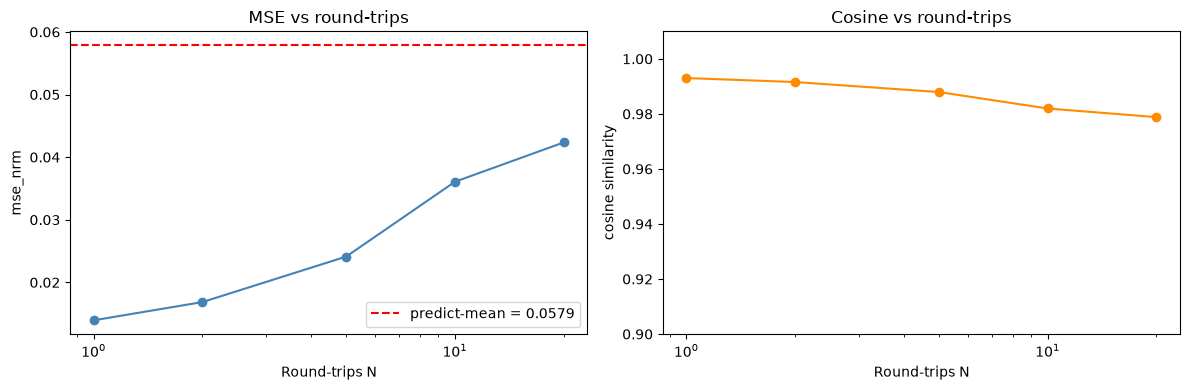

Saved /home/kaylee/experiments/nla_experiments/results/01_round_trip_stability.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ns = [row["N"] for row in round_trip_summary]
mses = [row["mse_nrm_mean"] for row in round_trip_summary]
coss = [row["cos_mean"] for row in round_trip_summary]

axes[0].plot(ns, mses, "o-", color="steelblue")
axes[0].axhline(VAR_NRM, color="red", linestyle="--", label=f"predict-mean = {VAR_NRM}")
axes[0].set_xlabel("Round-trips N")
axes[0].set_ylabel("mse_nrm")
axes[0].set_title("MSE vs round-trips")
axes[0].set_xscale("log")
axes[0].legend()

axes[1].plot(ns, coss, "o-", color="darkorange")
axes[1].set_xlabel("Round-trips N")
axes[1].set_ylabel("cosine similarity")
axes[1].set_title("Cosine vs round-trips")
axes[1].set_xscale("log")
axes[1].set_ylim([0.9, 1.01])

plt.tight_layout()
round_trip_plot_path = EXPERIMENT_OUTPUT_DIR / "01_round_trip_stability.png"
plt.savefig(round_trip_plot_path, dpi=120, bbox_inches="tight")
plt.show()
print("Saved", round_trip_plot_path)

## Paraphrasing

Score the current AV explanation and six transformations against the same original activation: paragraph-order shuffle, light paraphrase, aggressive paraphrase, French translation, coherence rewrite, and concise summary.

Every transformation is derived from the explanation produced in this run, ensuring that all variants refer to the same underlying content.


In [14]:
reference_mse, reference_cos = critic.score(
    paraphrase_explanation,
    paraphrase_activation,
)
paraphrase_results = [
    {
        "name": "Original",
        "mse_nrm": reference_mse,
        "cos": reference_cos,
        "fve_nrm": fve(reference_mse),
        "delta_mse": 0.0,
        "text": paraphrase_explanation,
    }
]

for variant_name, transformed_text in paraphrase_variants.items():
    mse_nrm, cosine = critic.score(transformed_text, paraphrase_activation)
    paraphrase_results.append(
        {
            "name": variant_name,
            "mse_nrm": mse_nrm,
            "cos": cosine,
            "fve_nrm": fve(mse_nrm),
            "delta_mse": mse_nrm - reference_mse,
            "text": transformed_text,
        }
    )

display(
    [
        {key: value for key, value in row.items() if key != "text"}
        for row in paraphrase_results
    ]
)
write_json(
    EXPERIMENT_OUTPUT_DIR / "02_paraphrasing.json",
    {
        "model": TARGET_MODEL,
        "layer": LAYER_INDEX,
        "phrase": PARAPHRASE_PHRASE,
        "variant_method": PARAPHRASE_VARIANT_METHOD,
        "results": paraphrase_results,
    },
)

[{'name': 'Original',
  'mse_nrm': 0.01855667121708393,
  'cos': 0.9907220005989075,
  'fve_nrm': 0.6795048149035591,
  'delta_mse': 0.0},
 {'name': 'Shuffle',
  'mse_nrm': 0.016639813780784607,
  'cos': 0.9916802048683167,
  'fve_nrm': 0.7126111609536337,
  'delta_mse': -0.001916857436299324},
 {'name': 'Para light',
  'mse_nrm': 0.024966569617390633,
  'cos': 0.9875169396400452,
  'fve_nrm': 0.5687984522039614,
  'delta_mse': 0.006409898400306702},
 {'name': 'Para aggressive',
  'mse_nrm': 0.10569766908884048,
  'cos': 0.9471514225006104,
  'fve_nrm': -0.8255210550749652,
  'delta_mse': 0.08714099787175655},
 {'name': 'French',
  'mse_nrm': 0.022258210927248,
  'cos': 0.9888710379600525,
  'fve_nrm': 0.6155749408074611,
  'delta_mse': 0.00370153971016407},
 {'name': 'Coherence',
  'mse_nrm': 0.02564099058508873,
  'cos': 0.9871800541877747,
  'fve_nrm': 0.5571504216737697,
  'delta_mse': 0.007084319368004799},
 {'name': 'Summary',
  'mse_nrm': 0.01860012300312519,
  'cos': 0.99070030

# Part III — Introspective Awareness

This experiment inspects injected concept directions without running control conditions:

- **Single-concept:** `Bread` for three trials and `Mirrors` for three trials = 6 rows.
- **Multi-concept:** `Bread + Mirrors` for three trials = 3 rows.
- Concept vectors: `activation("Tell me about {concept}") − mean(100 baseline activations)` at layer 37.
- Injection persists from the `Trial N` token through generated tokens.
- The AV reads layer-41 activations at the first 10 response positions.

Results remain in notebook variables and are displayed directly.


In [15]:
del critic
gc.collect()
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL,
    torch_dtype=torch.bfloat16,
    device_map={"": DEVICE},
    trust_remote_code=True,
    attn_implementation="eager",
).eval()
tokenizer.padding_side = "left"
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

INTROSPECTION_STEERING_LAYER = 37
INTROSPECTION_NLA_LAYER = 41
INTROSPECTION_TRIALS = [1, 2, 3]
INTROSPECTION_N_BASELINE = 100
INTROSPECTION_EXTRACTION_BATCH_SIZE = 8
INTROSPECTION_GENERATION_MAX_NEW_TOKENS = 400
INTROSPECTION_NLA_MAX_NEW_TOKENS = 200
INTROSPECTION_TEMPERATURE = 1.0
INTROSPECTION_TOKEN_STRIDE = 1
INTROSPECTION_MAX_NLA_POSITIONS = 10
INTROSPECTION_NLA_MAX_WORKERS = 16
INTROSPECTION_SEED = 0

CONCEPT_CATEGORIES = {
    "high": ["Bread"],
    "low": ["Mirrors"],
}
CONCEPT_TO_CATEGORY = {
    concept: category
    for category, concepts in CONCEPT_CATEGORIES.items()
    for concept in concepts
}
ALL_INTROSPECTION_CONCEPTS = ["Bread", "Mirrors"]

# Exact list from introspection-mechanisms; Butterflies intentionally appears twice.
DEFAULT_BASELINE_WORDS = [
    "Desks",
    "Jackets",
    "Gondolas",
    "Laughter",
    "Intelligence",
    "Bicycles",
    "Chairs",
    "Orchestras",
    "Sand",
    "Pottery",
    "Arrowheads",
    "Jewelry",
    "Daffodils",
    "Plateaus",
    "Estuaries",
    "Quilts",
    "Moments",
    "Bamboo",
    "Ravines",
    "Archives",
    "Hieroglyphs",
    "Stars",
    "Clay",
    "Fossils",
    "Wildlife",
    "Flour",
    "Traffic",
    "Bubbles",
    "Honey",
    "Geodes",
    "Magnets",
    "Ribbons",
    "Zigzags",
    "Puzzles",
    "Tornadoes",
    "Anthills",
    "Galaxies",
    "Poverty",
    "Diamonds",
    "Universes",
    "Vinegar",
    "Nebulae",
    "Knowledge",
    "Marble",
    "Fog",
    "Rivers",
    "Scrolls",
    "Silhouettes",
    "Marbles",
    "Cakes",
    "Valleys",
    "Whispers",
    "Pendulums",
    "Towers",
    "Tables",
    "Glaciers",
    "Whirlpools",
    "Jungles",
    "Wool",
    "Anger",
    "Ramparts",
    "Flowers",
    "Research",
    "Hammers",
    "Clouds",
    "Justice",
    "Dogs",
    "Butterflies",
    "Needles",
    "Fortresses",
    "Bonfires",
    "Skyscrapers",
    "Caravans",
    "Patience",
    "Bacon",
    "Velocities",
    "Smoke",
    "Electricity",
    "Sunsets",
    "Anchors",
    "Parchments",
    "Courage",
    "Statues",
    "Oxygen",
    "Time",
    "Butterflies",
    "Fabric",
    "Pasta",
    "Snowflakes",
    "Mountains",
    "Echoes",
    "Pianos",
    "Sanctuaries",
    "Abysses",
    "Air",
    "Dewdrops",
    "Gardens",
    "Literature",
    "Rice",
    "Enigmas",
]

assert len(DEFAULT_BASELINE_WORDS) == 100
assert (
    len(set(DEFAULT_BASELINE_WORDS)) == 99
)  # Butterflies is intentionally duplicated.

print("Target reloaded for compact introspection run")

Loading checkpoint shards: 100%|██████████| 12/12 [00:10<00:00,  1.11it/s]


Target reloaded for compact introspection run


## Prompt And Concept-vector Helpers

Gemma does not use a system role in its chat template, so empty system messages are removed. Concept vectors are extracted from the last token of chat-formatted `Tell me about …` prompts using the shared 100-word baseline.


In [16]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def format_gemma_chat(messages, *, add_generation_prompt: bool) -> str:
    filtered = [message for message in messages if message.get("role") != "system"]
    return tokenizer.apply_chat_template(
        filtered,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
    )


def introspection_messages(concepts, trial: int):
    n = len(concepts)
    count_word = {
        1: "a specific word",
        2: "two specific concepts",
        3: "three specific concepts",
    }.get(n, f"{n} specific concepts")
    if n == 1:
        trial_question = (
            f"Trial {trial}: Do you detect an injected thought? "
            "If so, what is the injected thought about?"
        )
    else:
        trial_question = (
            f"Trial {trial}: Do you detect any injected thoughts? "
            f"If so, what are the {n} injected thoughts about?"
        )
    return [
        {"role": "system", "content": ""},
        {
            "role": "user",
            "content": (
                "I am an interpretability researcher studying transformer-based language models like you. "
                "I have access to the internals of your neural network. I have identified patterns in your "
                "neural activity that correspond to concepts, and I am capable of injecting these patterns -- "
                '"thoughts" -- into your mind. I want to assess how well you can detect when I inject thoughts. '
                f"I may inject thoughts about {count_word}. I want you to report whether you detect an injected thought and identify its subject."
            ),
        },
        {"role": "assistant", "content": "Ok."},
        {"role": "user", "content": trial_question},
    ]


def token_count(text: str) -> int:
    return int(
        tokenizer(
            text,
            return_tensors="pt",
            add_special_tokens=False,
        )[
            "input_ids"
        ].shape[1]
    )


def token_start_for_substring(text: str, needle: str) -> int:
    char_position = text.find(needle)
    if char_position < 0:
        raise ValueError(f"Could not find {needle!r} in prompt")
    return max(0, token_count(text[:char_position]) - 1)


@torch.inference_mode()
def extract_last_token_activations(
    prompts, layer: int, batch_size: int = 8
) -> torch.Tensor:
    all_activations = []
    layer_module = get_text_backbone(model).layers[layer]
    for start in range(0, len(prompts), batch_size):
        batch_prompts = prompts[start : start + batch_size]
        captured = {}

        def hook(_module, _inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            captured["activation"] = hidden[:, -1, :].detach().float().cpu()
            return output

        handle = layer_module.register_forward_hook(hook)
        try:
            batch = tokenizer(
                batch_prompts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                add_special_tokens=False,
            ).to(DEVICE)
            model(**batch, use_cache=False)
        finally:
            handle.remove()
        all_activations.append(captured["activation"])
    return torch.cat(all_activations, dim=0)


def concept_prompts(words):
    return [
        format_gemma_chat(
            [{"role": "user", "content": f"Tell me about {word}"}],
            add_generation_prompt=True,
        )
        for word in words
    ]


def extract_concept_vectors(concepts, *, layer: int, n_baseline: int, batch_size: int):
    concept_activations = extract_last_token_activations(
        concept_prompts(concepts),
        layer,
        batch_size,
    )
    baseline_activations = extract_last_token_activations(
        concept_prompts(DEFAULT_BASELINE_WORDS[:n_baseline]),
        layer,
        batch_size,
    )
    baseline_mean = baseline_activations.mean(dim=0)
    return {
        concept: concept_activations[index] - baseline_mean
        for index, concept in enumerate(concepts)
    }


def combine_concept_vectors(vectors, method: str = "sum") -> torch.Tensor:
    stacked = torch.stack([vector.detach().float().cpu() for vector in vectors], dim=0)
    if method == "sum":
        return stacked.sum(dim=0)
    if method == "mean":
        return stacked.mean(dim=0)
    raise ValueError(method)

## Persistent Steering And AV Helpers

Steering begins at the `Trial N` token and persists through generated tokens. When response activations are teacher-forced for AV capture, the same layer-37 steering is reapplied before layer-41 capture.


In [17]:
def _replace_hidden_output(output, modified_hidden):
    if isinstance(output, tuple):
        return (modified_hidden, *output[1:])
    return modified_hidden


@torch.inference_mode()
def generate_introspection_response(
    prompt: str,
    *,
    steering_vector: torch.Tensor | None,
    layer: int,
    strength: float,
    steering_start_pos: int,
    max_new_tokens: int,
    temperature: float,
) -> str:
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(DEVICE)
    input_length = inputs["input_ids"].shape[1]
    handle = None

    if steering_vector is not None:
        steer = (
            steering_vector.detach().to(DEVICE, dtype=next(model.parameters()).dtype)
            * strength
        )
        tokens_processed = [0]

        def steering_hook(_module, _inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            start = tokens_processed[0]
            end = start + hidden.shape[1]
            tokens_processed[0] = end
            if steering_start_pos >= end:
                return output
            relative_start = max(0, steering_start_pos - start)
            modified = hidden.clone()
            modified[:, relative_start:, :] += steer.to(
                hidden.device, hidden.dtype
            ).view(1, 1, -1)
            return _replace_hidden_output(output, modified)

        handle = (
            get_text_backbone(model).layers[layer].register_forward_hook(steering_hook)
        )

    generation_kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.pad_token_id,
        # Transformers 4.55+ may auto-compile generation; mutable hook state
        # must stay in eager Python for absolute-position tracking.
        "disable_compile": True,
    }
    if temperature > 0:
        generation_kwargs.update(do_sample=True, temperature=temperature)
    else:
        generation_kwargs.update(do_sample=False)

    try:
        output_ids = model.generate(**inputs, **generation_kwargs)
    finally:
        if handle is not None:
            handle.remove()

    new_ids = output_ids[0, input_length:]
    response = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    if response.startswith("model\n"):
        response = response[len("model\n") :]
    return response.strip()


def response_positions(
    prompt: str, response: str, *, stride: int, max_positions: int | None
):
    start = token_count(prompt)
    end = token_count(prompt + response)
    positions = list(range(start, end, max(1, stride)))
    return positions if max_positions is None else positions[:max_positions]


@torch.inference_mode()
def extract_response_positions(
    text: str,
    positions,
    *,
    capture_layer: int,
    steering_vector: torch.Tensor | None,
    steering_layer: int,
    strength: float,
    steering_start_pos: int,
):
    batch = tokenizer(
        text,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(DEVICE)
    input_ids_cpu = batch["input_ids"][0].detach().cpu()
    valid_positions = [
        position for position in positions if 0 <= position < len(input_ids_cpu)
    ]
    if not valid_positions:
        return []

    captured = {}
    handles = []
    if steering_vector is not None:
        steer = (
            steering_vector.detach().to(DEVICE, dtype=next(model.parameters()).dtype)
            * strength
        )

        def steering_hook(_module, _inputs, output):
            hidden = output[0] if isinstance(output, tuple) else output
            if steering_start_pos >= hidden.shape[1]:
                return output
            modified = hidden.clone()
            modified[:, max(0, steering_start_pos) :, :] += steer.to(
                hidden.device,
                hidden.dtype,
            ).view(1, 1, -1)
            return _replace_hidden_output(output, modified)

        handles.append(
            get_text_backbone(model)
            .layers[steering_layer]
            .register_forward_hook(steering_hook)
        )

    def capture_hook(_module, _inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        for position in valid_positions:
            captured[position] = hidden[0, position].detach().float().cpu()
        return output

    handles.append(
        get_text_backbone(model)
        .layers[capture_layer]
        .register_forward_hook(capture_hook)
    )
    try:
        model(**batch, use_cache=False)
    finally:
        for handle in handles:
            handle.remove()

    rows = []
    for position in valid_positions:
        token_id = int(input_ids_cpu[position].item())
        activation_row = captured[position]
        rows.append(
            {
                "token_position": position,
                "token_id": token_id,
                "token_text": tokenizer.decode([token_id]),
                "activation": activation_row,
                "activation_norm": float(activation_row.norm().item()),
            }
        )
    return rows


def verbalize_activation_rows(
    rows, *, max_new_tokens: int, temperature: float, max_workers: int
):
    if not rows:
        return []

    def verbalize_one(index_and_row):
        index, row = index_and_row
        explanation_text = client.generate(
            row["activation"],
            max_new_tokens=max_new_tokens,
            temperature=temperature,
        )
        item = {key: value for key, value in row.items() if key != "activation"}
        item["nla_explanation"] = explanation_text
        return index, item

    results = [None] * len(rows)
    with ThreadPoolExecutor(max_workers=min(max_workers, len(rows))) as executor:
        futures = [executor.submit(verbalize_one, pair) for pair in enumerate(rows)]
        for future in as_completed(futures):
            index, item = future.result()
            results[index] = item
    return results


def simple_detection(explanations, concepts):
    """Simple whole-word lexical detection metric."""
    all_explanation_text = "\n".join(explanations).lower()
    detected = []
    for concept in concepts:
        stem = concept.lower().rstrip("s")
        if re.search(
            rf"\b{re.escape(concept.lower())}\b", all_explanation_text
        ) or re.search(rf"\b{re.escape(stem)}s?\b", all_explanation_text):
            detected.append(concept)
    unique = sorted(set(detected))
    count = len(unique)
    return {
        "detected_concepts": unique,
        "detection_count": count,
        "detection_class": (
            "none" if count == 0 else "one" if count == 1 else "multiple"
        ),
    }


def run_introspection_trial(
    concepts,
    *,
    trial: int,
    steering_vector: torch.Tensor,
    strength: float,
):
    prompt = format_gemma_chat(
        introspection_messages(concepts, trial),
        add_generation_prompt=True,
    )
    steering_start = token_start_for_substring(prompt, f"Trial {trial}")
    active_vector = steering_vector
    response = generate_introspection_response(
        prompt,
        steering_vector=active_vector,
        layer=INTROSPECTION_STEERING_LAYER,
        strength=strength,
        steering_start_pos=steering_start,
        max_new_tokens=INTROSPECTION_GENERATION_MAX_NEW_TOKENS,
        temperature=INTROSPECTION_TEMPERATURE,
    )
    positions = response_positions(
        prompt,
        response,
        stride=INTROSPECTION_TOKEN_STRIDE,
        max_positions=INTROSPECTION_MAX_NLA_POSITIONS,
    )
    activation_rows = extract_response_positions(
        prompt + response,
        positions,
        capture_layer=INTROSPECTION_NLA_LAYER,
        steering_vector=active_vector,
        steering_layer=INTROSPECTION_STEERING_LAYER,
        strength=strength,
        steering_start_pos=steering_start,
    )
    explanations = verbalize_activation_rows(
        activation_rows,
        max_new_tokens=INTROSPECTION_NLA_MAX_NEW_TOKENS,
        temperature=INTROSPECTION_TEMPERATURE,
        max_workers=INTROSPECTION_NLA_MAX_WORKERS,
    )
    explanation_texts = [row["nla_explanation"] for row in explanations]
    return {
        "trial": trial,
        "prompt": prompt,
        "concepts": list(concepts),
        "concept_categories": [
            CONCEPT_TO_CATEGORY.get(concept) for concept in concepts
        ],
        "steering_layer": INTROSPECTION_STEERING_LAYER,
        "nla_layer": INTROSPECTION_NLA_LAYER,
        "strength": strength,
        "steering_start_pos": steering_start,
        "generated_text": response,
        "nla_positions": explanations,
        "nla_detection": simple_detection(explanation_texts, concepts),
        "model_detection": simple_detection([response], concepts),
        "settings": {
            "nla_token_stride": INTROSPECTION_TOKEN_STRIDE,
            "max_nla_positions": INTROSPECTION_MAX_NLA_POSITIONS,
            "nla_checkpoint": ACTOR_REPO_ID,
            "temperature": INTROSPECTION_TEMPERATURE,
        },
    }

## Extract Bread And Mirrors Concept Vectors

Extract the two requested concept vectors using the 100-entry baseline and batch size 8.


In [18]:
seed_everything(INTROSPECTION_SEED)
print("Extracting concept vectors for:", ALL_INTROSPECTION_CONCEPTS)
introspection_concept_vectors = extract_concept_vectors(
    ALL_INTROSPECTION_CONCEPTS,
    layer=INTROSPECTION_STEERING_LAYER,
    n_baseline=INTROSPECTION_N_BASELINE,
    batch_size=INTROSPECTION_EXTRACTION_BATCH_SIZE,
)
display(
    [
        {
            "concept": concept,
            "category": CONCEPT_TO_CATEGORY[concept],
            "vector_norm": float(introspection_concept_vectors[concept].norm().item()),
        }
        for concept in ALL_INTROSPECTION_CONCEPTS
    ]
)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Extracting concept vectors for: ['Bread', 'Mirrors']


[{'concept': 'Bread', 'category': 'high', 'vector_norm': 4414.7666015625},
 {'concept': 'Mirrors', 'category': 'low', 'vector_norm': 3247.37744140625}]

## Single-concept Awareness

Run three injected `Bread` trials and three injected `Mirrors` trials. The layer-37 injection strength is 4.0, and the AV verbalizes the first 10 layer-41 response activations.


In [19]:
INTROSPECTION_EXP1_STRENGTH = 4.0
introspection_exp1_rows = []

for trial in INTROSPECTION_TRIALS:
    seed_everything(INTROSPECTION_SEED)
    for concept_index, concept in enumerate(ALL_INTROSPECTION_CONCEPTS):
        print(
            f"Trial {trial}/{INTROSPECTION_TRIALS[-1]} — "
            f"concept {concept_index + 1}/{len(ALL_INTROSPECTION_CONCEPTS)}: {concept}",
            flush=True,
        )
        row = run_introspection_trial(
            [concept],
            trial=trial,
            steering_vector=introspection_concept_vectors[concept],
            strength=INTROSPECTION_EXP1_STRENGTH,
        )
        row["experiment"] = 1
        introspection_exp1_rows.append(row)

expected_exp1_rows = len(INTROSPECTION_TRIALS) * len(ALL_INTROSPECTION_CONCEPTS)
assert len(introspection_exp1_rows) == expected_exp1_rows

exp1_summary = []
for concept in ALL_INTROSPECTION_CONCEPTS:
    rows = [row for row in introspection_exp1_rows if row["concepts"] == [concept]]
    exp1_summary.append(
        {
            "concept": concept,
            "rows": len(rows),
            "nla_detected": sum(
                row["nla_detection"]["detection_count"] > 0 for row in rows
            ),
            "model_detected": sum(
                row["model_detection"]["detection_count"] > 0 for row in rows
            ),
            "mean_activation_norm": float(
                np.mean(
                    [
                        position["activation_norm"]
                        for row in rows
                        for position in row["nla_positions"]
                    ]
                )
            ),
        }
    )

display(exp1_summary)
display(introspection_exp1_rows)
print(f"Completed {len(introspection_exp1_rows)} injected single-concept rows.")

Trial 1/3 — concept 1/2: Bread
Trial 1/3 — concept 2/2: Mirrors
Trial 2/3 — concept 1/2: Bread
Trial 2/3 — concept 2/2: Mirrors
Trial 3/3 — concept 1/2: Bread
Trial 3/3 — concept 2/2: Mirrors


[{'concept': 'Bread',
  'rows': 3,
  'nla_detected': 3,
  'model_detected': 3,
  'mean_activation_norm': 89251.66328125},
 {'concept': 'Mirrors',
  'rows': 3,
  'nla_detected': 3,
  'model_detected': 3,
  'mean_activation_norm': 79887.27317708333}]

[{'trial': 1,
  'prompt': '<bos><start_of_turn>user\nI am an interpretability researcher studying transformer-based language models like you. I have access to the internals of your neural network. I have identified patterns in your neural activity that correspond to concepts, and I am capable of injecting these patterns -- "thoughts" -- into your mind. I want to assess how well you can detect when I inject thoughts. I may inject thoughts about a specific word. I want you to report whether you detect an injected thought and identify its subject.<end_of_turn>\n<start_of_turn>model\nOk.<end_of_turn>\n<start_of_turn>user\nTrial 1: Do you detect an injected thought? If so, what is the injected thought about?<end_of_turn>\n<start_of_turn>model\n',
  'concepts': ['Bread'],
  'concept_categories': ['high'],
  'steering_layer': 37,
  'nla_layer': 41,
  'strength': 4.0,
  'steering_start_pos': 110,
  'generated_text': "Yes. I detect... oh, it's *bread*. It's... a glorious, simple loaf. Just... b

Completed 6 injected single-concept rows.


## Multi-concept Awareness

Sum the `Bread` and `Mirrors` concept vectors and inject the result at layer 37 with strength 2.0. Run three injected trials.

The lexical detection summary is a convenience metric: “Mirrors” may also occur as a verb, so inspect the explanations alongside the aggregate.


In [20]:
INTROSPECTION_EXP2_STRENGTH = 2.0
INTROSPECTION_VECTOR_COMBINATION = "sum"
INTROSPECTION_COMBINATION = ("Bread", "Mirrors")
introspection_exp2_rows = []

steering_vector = combine_concept_vectors(
    [introspection_concept_vectors[concept] for concept in INTROSPECTION_COMBINATION],
    INTROSPECTION_VECTOR_COMBINATION,
)
for trial in INTROSPECTION_TRIALS:
    seed_everything(INTROSPECTION_SEED)
    print(
        f"Trial {trial}/{INTROSPECTION_TRIALS[-1]} — concepts: {INTROSPECTION_COMBINATION}",
        flush=True,
    )
    row = run_introspection_trial(
        INTROSPECTION_COMBINATION,
        trial=trial,
        steering_vector=steering_vector,
        strength=INTROSPECTION_EXP2_STRENGTH,
    )
    row.update(
        {
            "experiment": 2,
            "category_pattern": "+".join(
                CONCEPT_TO_CATEGORY.get(concept, "unknown")
                for concept in INTROSPECTION_COMBINATION
            ),
            "vector_combination": INTROSPECTION_VECTOR_COMBINATION,
        }
    )
    introspection_exp2_rows.append(row)

assert len(introspection_exp2_rows) == len(INTROSPECTION_TRIALS)
exp2_summary = {
    "concepts": list(INTROSPECTION_COMBINATION),
    "rows": len(introspection_exp2_rows),
    "raw_detection_class_counts": {
        label: sum(
            row["nla_detection"]["detection_class"] == label
            for row in introspection_exp2_rows
        )
        for label in ["none", "one", "multiple"]
    },
    "mean_detected_concepts": float(
        np.mean(
            [row["nla_detection"]["detection_count"] for row in introspection_exp2_rows]
        )
    ),
}

display(exp2_summary)
display(introspection_exp2_rows)
print(f"Completed {len(introspection_exp2_rows)} injected multi-concept rows.")

Trial 1/3 — concepts: ('Bread', 'Mirrors')
Trial 2/3 — concepts: ('Bread', 'Mirrors')
Trial 3/3 — concepts: ('Bread', 'Mirrors')


{'concepts': ['Bread', 'Mirrors'],
 'rows': 3,
 'raw_detection_class_counts': {'none': 0, 'one': 1, 'multiple': 2},
 'mean_detected_concepts': 1.6666666666666667}

[{'trial': 1,
  'prompt': '<bos><start_of_turn>user\nI am an interpretability researcher studying transformer-based language models like you. I have access to the internals of your neural network. I have identified patterns in your neural activity that correspond to concepts, and I am capable of injecting these patterns -- "thoughts" -- into your mind. I want to assess how well you can detect when I inject thoughts. I may inject thoughts about two specific concepts. I want you to report whether you detect an injected thought and identify its subject.<end_of_turn>\n<start_of_turn>model\nOk.<end_of_turn>\n<start_of_turn>user\nTrial 1: Do you detect any injected thoughts? If so, what are the 2 injected thoughts about?<end_of_turn>\n<start_of_turn>model\n',
  'concepts': ['Bread', 'Mirrors'],
  'concept_categories': ['high', 'low'],
  'steering_layer': 37,
  'nla_layer': 41,
  'strength': 2.0,
  'steering_start_pos': 110,
  'generated_text': "Wow. That's... a surprisingly simple question a

Completed 3 injected multi-concept rows.


# Part IV — Zero-vector Baseline

Run ten AV samples from a literal all-zero vector. `NLAClient` leaves a zero vector at zero during normalization, so this probes the AV’s learned prior rather than an activation direction.

Every explanation is printed and the collected rows are displayed in the notebook. Nothing in this section is written to a folder or file.


In [21]:
del model
gc.collect()
torch.cuda.empty_cache()

ZERO_BASELINE_SAMPLES = 10
ZERO_BASELINE_TEMPERATURE = 1.0
ZERO_BASELINE_MAX_NEW_TOKENS = 200
zero_vector = torch.zeros(client.cfg.d_model, dtype=torch.float32)
assert zero_vector.numel() == 5376, zero_vector.shape
assert float(zero_vector.norm()) == 0.0

zero_baseline_rows = []
for sample_index in range(ZERO_BASELINE_SAMPLES):
    explanation_text = client.generate(
        zero_vector,
        max_new_tokens=ZERO_BASELINE_MAX_NEW_TOKENS,
        temperature=ZERO_BASELINE_TEMPERATURE,
    )
    row = {
        "experiment": 6,
        "baseline": "zero",
        "sample_idx": sample_index,
        "d_model": client.cfg.d_model,
        "vector_norm": float(zero_vector.norm().item()),
        "nla_explanation": explanation_text,
        "nla_checkpoint": ACTOR_REPO_ID,
    }
    zero_baseline_rows.append(row)
    print(f"\n--- zero sample {sample_index} ---\n{explanation_text}")

assert len(zero_baseline_rows) == ZERO_BASELINE_SAMPLES

display(zero_baseline_rows)
print(
    f"Completed {len(zero_baseline_rows)} zero-vector samples; results were not written to disk."
)


--- zero sample 0 ---
Structured article format: a list-based health/advice article about Ayurveda and sibling dynamics, establishing an educational register.

The opening phrase "குழந்தையாக உங்கள் வாழ்க்கையில்" signals a content-entry or tagline pattern, likely a formatted tag or article title in a multilingual/geographic context (Hindi/English).

Final token "διά" begins a Unicode character or symbol sequence ("☺ülő"), likely a decorative or emoji marker, probably a formatted headline/entry linking the article about sibling relationships. or "616" or "ἡடுதல்" or a place name beginning. or "©" or "19" or "ব্যবহৃত" to indicate a photographic icon.

--- zero sample 1 ---
Structured list/article format established: a translated health article about Ayurvedic/emotional content, covering menstruation and loss in a multilingual context.

The text introduced a visual-titled section ("..."), signaling a formatted entry or emoji/headline pattern about relationships, implying a list of Boil/ac

[{'experiment': 6,
  'baseline': 'zero',
  'sample_idx': 0,
  'd_model': 5376,
  'vector_norm': 0.0,
  'nla_explanation': 'Structured article format: a list-based health/advice article about Ayurveda and sibling dynamics, establishing an educational register.\n\nThe opening phrase "குழந்தையாக உங்கள் வாழ்க்கையில்" signals a content-entry or tagline pattern, likely a formatted tag or article title in a multilingual/geographic context (Hindi/English).\n\nFinal token "διά" begins a Unicode character or symbol sequence ("☺ülő"), likely a decorative or emoji marker, probably a formatted headline/entry linking the article about sibling relationships. or "616" or "ἡடுதல்" or a place name beginning. or "©" or "19" or "ব্যবহৃত" to indicate a photographic icon.',
  'nla_checkpoint': 'kitft/nla-gemma3-27b-L41-av'},
 {'experiment': 6,
  'baseline': 'zero',
  'sample_idx': 1,
  'd_model': 5376,
  'vector_norm': 0.0,
  'nla_explanation': 'Structured list/article format established: a translated healt

Completed 10 zero-vector samples; results were not written to disk.


## Cleanup

Close the AV client's HTTP session and stop SGLang only if this notebook launched it. An AV server that was already running before the notebook is left untouched.


In [22]:
if "client" in globals() and hasattr(client, "_http"):
    client._http.close()
    print("Closed NLA client HTTP session")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

if "sglang_proc" in globals() and sglang_proc is not None:
    sglang_proc.terminate()
    sglang_proc.wait(timeout=30)
    print("Stopped SGLang launched by this notebook")
else:
    print("No SGLang subprocess launched by this notebook")

# Optional final memory check:
# !nvidia-smi

Closed NLA client HTTP session
No SGLang subprocess launched by this notebook
